# Privacy-Preserving EEG-Connectivity ADHD vs. Control Classification with CKKS Encrypted Inference

## Research question
Can an HE-compatible neural architecture classify EEG connectivity matrices while enabling end-to-end encrypted inference, and what accuracy, numerical-fidelity and computational trade-offs result?

## Design
EEG functional-connectivity matrices ($N_{elec}\times N_{elec}$; the size and electrode labels are read from the data) are classified by three variants evaluated with **repeated nested, subject-level cross-validation** (outer test folds are never used for model selection):
1. **V1 – Standard CNN** (BatchNorm + ReLU).
2. **V2 – HE-compatible CNN** (zero bias, square activation), evaluated in plaintext.
3. **V3 – The same V2 network evaluated under CKKS (TenSEAL)** in a client/server setting.

**V1 vs V2** measures the accuracy cost of HE-compatibility. **V2 vs V3** isolates the effect of encryption and is assessed by prediction agreement and numerical error over *all* evaluation samples. Classical baselines (LR, SVM, RF, XGBoost) use the same splits. Grad-CAM is computed only on held-out subjects.

This is a **privacy-preserving ADHD classification research prototype**, not a clinical diagnostic system.

## How to run
- Data layout: `data/adhd/*.csv` and `data/control/*.csv` (each CSV: header row + index column of electrode labels).
- `pip install torch tenseal scikit-learn statsmodels scipy pandas matplotlib xgboost psutil` (xgboost and psutil are optional).
- Edit the `CFG` block in Section 2 if needed (e.g. `subject_id_regex` if one participant has several files). Quick trial: `n_repeats=1`, `he_max_samples_per_fold=2`; paper run: `n_repeats=3`, `he_max_samples_per_fold=None` (encrypts every held-out sample, ~5 s each).
- Kernel → Restart & Run All. Everything is written to `results/`.


## Section 1: Mathematical Foundations & Theoretical Framework

### 1.1 Homomorphic Encryption via the CKKS Scheme
The **Cheon-Kim-Kim-Song (CKKS)** scheme is based on the Ring Learning With Errors (RLWE) hardness assumption over polynomial ring $R_q = \mathbb{Z}_q[X]/(X^N + 1)$, where $N$ is a power-of-two polynomial degree ($N = 16384$).

- **SIMD Vector Packing:** Encodes a vector of real numbers $\mathbf{z} \in \mathbb{R}^{N/2}$ into a single ciphertext:
  $$\mathbf{c} = (c_0, c_1) \in R_q \times R_q, \quad c_0 + c_1 \cdot s \approx \Delta \cdot m(X) + e$$
  where $s$ is the secret key, $\Delta = 2^{40}$ is the scaling factor, and $e$ is small gaussian noise.
- **Multiplicative Depth Budget:** Every multiplication (ciphertext×plaintext matrix or ciphertext×ciphertext) is followed by a rescale that consumes one 40-bit prime. This network needs three (matmul, square, matmul). The chain therefore has three 40-bit middle primes, a 60-bit first prime that must hold the scale plus the output magnitude (20 bits of headroom), and a 60-bit special prime for key switching. The total is 240 bits, below the 438 bits allowed for 128-bit security at $N=16384$. Relinearization keys (square) and Galois keys (vector–matrix products) are required. Parameters used:
  $$\text{poly\_modulus\_degree} = 16384, \quad \text{coeff\_mod\_bit\_sizes} = [60, 40, 40, 40, 60], \quad \text{scale} = 2^{40}$$

### 1.2 Zero-Bias Matrix Unrolling
Because homomorphic evaluations cannot evaluate piecewise non-linearities (like ReLU) without high-degree polynomial approximations, Variant 2 replaces ReLU with an exact square activation ($x \mapsto x^2$) and eliminates additive bias terms. This decomposes the entire network into:
1. **Layer 1 (Linear Convolution):** $W_{\text{conv1}} \in \mathbb{R}^{361 \times 400}$, computed as $\mathbf{h}_1 = \text{Enc}(\mathbf{x}) \cdot W_{\text{conv1}}$.
2. **Square Activation:** $\mathbf{h}_{\text{sq}} = \mathbf{h}_1 \odot \mathbf{h}_1$ (Consumes 1 multiplication depth level).
3. **Composite Linear Stage:** Conv2, Average Pooling, and FC layers are purely linear and collapse into a single matrix $W_{\text{final}} \in \mathbb{R}^{400 \times 2}$:
   $$\hat{\mathbf{y}}_{\text{enc}} = \mathbf{h}_{\text{sq}} \cdot W_{\text{final}}$$

### 1.3 Statistical analysis
- **V2 vs V3:** prediction agreement, disagreement rate, and mean/median/p95/max absolute logit error, relative error and logit correlation over all encrypted samples. An optional TOST equivalence test uses a margin declared *before* the analysis. A non-significant t-test is never interpreted as equivalence.
- **Model comparison:** Nadeau–Bengio corrected resampled t-test (Holm-adjusted) on repeated-CV fold results; exploratory given n = 121 subjects.
- **Uncertainty:** mean ± SD and 95% CI over outer folds, and a subject-level bootstrap CI on pooled out-of-fold predictions.

### 1.4 Grad-CAM Formulation for Connectivity Matrices
For class $c \in \{\text{Control}, \text{ADHD}\}$ and convolutional feature maps $A^k$:
$$\alpha_k^c = \frac{1}{Z}\sum_{i=1}^H \sum_{j=1}^W \frac{\partial y^c}{\partial A_{i,j}^k}, \quad L_{\text{Grad-CAM}}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$
The Population Difference Map is given by:
$$\Delta \text{Grad-CAM} = \overline{L}_{\text{ADHD}} - \overline{L}_{\text{Control}}$$

Maps are computed per fold model on that fold's **held-out subjects only**, symmetrised (cell $(i,j)$ and $(j,i)$ are the same electrode pair), and aggregated over fold models. They describe model attribution, not causal or clinical effects.


In [1]:
# ==============================================================================
# SECTION 2: Environment, configuration, reproducibility
# ==============================================================================
import os, re, sys, glob, time, json, random, platform, warnings
from pathlib import Path
from importlib import metadata as importlib_metadata
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, roc_auc_score,
                             average_precision_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import ttost_paired
import tenseal as ts

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    import psutil
except ImportError:
    psutil = None

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "sans-serif", "font.size": 10})

# ----------------------------- experiment configuration -----------------------------
CFG = dict(
    data_root="data", results_dir="results", seed=42,
    n_outer_folds=5, n_inner_folds=5, n_repeats=3,      # repeated nested CV
    epochs=40, patience=10, batch_size=16,
    lr_v1=0.003, lr_v2=0.004, weight_decay=1e-4,        # carried over from the original notebook (see Limitations)
    he_repeats=[0],                 # repeats on which encrypted inference is executed (~5 s / sample)
    he_max_samples_per_fold=None,   # None = encrypt EVERY held-out sample. Use an int ONLY for a quick smoke test.
    subject_id_regex=None,          # regex with one group that extracts the subject id from the file stem; None = one file per subject
    external_root=None,             # optional independent dataset folder (adhd/ and control/ sub-folders), Section 13
)
CKKS_CFG = dict(poly_modulus_degree=16384, coeff_mod_bit_sizes=[60, 40, 40, 40, 60], scale_bits=40)
EQUIV_MARGIN_LOGIT = 1e-3   # equivalence margin, declared BEFORE looking at any result (Section 8)

RESULTS = Path(CFG["results_dir"])
(RESULTS / "models").mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def rss_mb():
    return psutil.Process().memory_info().rss / 1e6 if psutil else float("nan")

def collect_environment() -> Dict[str, Any]:
    pkgs = ["numpy", "pandas", "scipy", "scikit-learn", "statsmodels", "torch", "tenseal", "xgboost", "matplotlib", "psutil"]
    versions = {}
    for p in pkgs:
        try:
            versions[p] = importlib_metadata.version(p)
        except importlib_metadata.PackageNotFoundError:
            versions[p] = None
    env = dict(python=sys.version.split()[0], os=platform.platform(),
               cpu=platform.processor() or platform.machine(), logical_cpus=os.cpu_count(),
               torch_threads=torch.get_num_threads(), packages=versions)
    if psutil:
        env["physical_cpus"] = psutil.cpu_count(logical=False)
        env["ram_gb"] = round(psutil.virtual_memory().total / 1e9, 1)
    return env

set_seed(CFG["seed"])
ENV = collect_environment()
json.dump(ENV, open(RESULTS / "environment.json", "w"), indent=2)
json.dump(dict(CFG=CFG, CKKS_CFG=CKKS_CFG, EQUIV_MARGIN_LOGIT=EQUIV_MARGIN_LOGIT), open(RESULTS / "config.json", "w"), indent=2)
with open("requirements.txt", "w") as fh:
    fh.writelines(f"{p}=={v}\n" for p, v in ENV["packages"].items() if v)

print("[Setup] Environment:", json.dumps({k: v for k, v in ENV.items() if k != "packages"}))
print("[Setup] Packages   :", {k: v for k, v in ENV["packages"].items() if v})
print("[Setup] Wrote requirements.txt, results/environment.json, results/config.json")


[Setup] Environment: {"python": "3.13.3", "os": "Windows-11-10.0.26200-SP0", "cpu": "Intel64 Family 6 Model 154 Stepping 3, GenuineIntel", "logical_cpus": 16, "torch_threads": 12, "physical_cpus": 12, "ram_gb": 16.8}
[Setup] Packages   : {'numpy': '2.4.4', 'pandas': '2.3.0', 'scipy': '1.16.2', 'scikit-learn': '1.8.0', 'statsmodels': '0.15.0', 'torch': '2.11.0', 'tenseal': '0.3.17', 'matplotlib': '3.10.8', 'psutil': '7.2.2'}
[Setup] Wrote requirements.txt, results/environment.json, results/config.json


In [2]:
# ==============================================================================
# SECTION 3: Dataset ingestion, preprocessing, subject IDs and data audit
# ==============================================================================
def read_matrix_csv(path: str):
    for enc in ("utf-8-sig", "utf-8", "latin-1"):
        try:
            df = pd.read_csv(path, index_col=0, encoding=enc)
            break
        except UnicodeDecodeError:
            continue
    return df.values.astype(np.float32), [str(c).strip() for c in df.columns], [str(i).strip() for i in df.index]

def zscore_per_sample(mat: np.ndarray) -> np.ndarray:
    """Uses ONLY the matrix itself, so no information flows between train and test samples.
    It can therefore run on the client, in plaintext, before encryption."""
    return (mat - mat.mean()) / (mat.std() + 1e-8)

def subject_id_from_path(path: str, cls: str) -> str:
    stem = Path(path).stem
    rx = CFG["subject_id_regex"]
    if rx:
        m = re.search(rx, stem)
        if m is None:
            raise ValueError(f"subject_id_regex '{rx}' did not match file stem '{stem}'")
        stem = m.group(1) if m.groups() else m.group(0)
    return f"{cls}/{stem}"          # class prefix prevents ID collisions between the two folders

def load_eeg_dataset(data_root: str):
    mats, labels, files, groups, header = [], [], [], [], None
    for cls, y_val in (("adhd", 1), ("control", 0)):
        for f in sorted(glob.glob(os.path.join(data_root, cls, "*.csv"))):
            mat, cols, rows = read_matrix_csv(f)
            if mat.ndim != 2 or mat.shape[0] != mat.shape[1]:
                raise ValueError(f"{f}: matrix is not square {mat.shape}")
            if not np.isfinite(mat).all():
                raise ValueError(f"{f}: contains NaN/inf")
            if header is None:
                header = cols
                if rows != cols:
                    print(f"[Dataset] WARNING: row labels differ from column labels in {f}")
            elif cols != header:
                raise ValueError(f"{f}: electrode labels differ from the first file")
            mats.append(mat); labels.append(y_val); files.append(f); groups.append(subject_id_from_path(f, cls))
    if not mats:
        raise FileNotFoundError(f"No CSV files found under '{data_root}/adhd' and '{data_root}/control'")
    if all(re.search(r"[A-Za-z]", c) for c in header):
        electrodes = header                                        # real labels read from the data itself
    else:
        electrodes = [f"Ch{i}" for i in range(len(header))]
        print("[Dataset] WARNING: CSV headers are not electrode names -> using generic Ch0..ChN labels. "
              "Attribution tables cannot be mapped to scalp locations until the true channel order is confirmed.")
    return np.stack(mats).astype(np.float32), np.array(labels, dtype=np.int64), files, np.array(groups), electrodes

def audit_dataset(X_raw, y, groups, files, electrodes, dup_threshold=0.995):
    rep = {}
    per_subj = pd.DataFrame({"g": groups, "y": y}).groupby("g").agg(n=("y", "size"), n_labels=("y", "nunique"))
    assert (per_subj.n_labels == 1).all(), "A subject appears with BOTH labels - fix subject_id_regex"
    y_subj = pd.DataFrame({"g": groups, "y": y}).drop_duplicates("g").set_index("g").y
    rep.update(n_samples=len(y), n_subjects=len(per_subj), n_adhd_subjects=int((y_subj == 1).sum()),
               n_control_subjects=int((y_subj == 0).sum()), samples_per_subject_min=int(per_subj.n.min()),
               samples_per_subject_max=int(per_subj.n.max()), n_electrodes=len(electrodes))
    asym = np.abs(X_raw - X_raw.transpose(0, 2, 1)).max(axis=(1, 2)) / (np.abs(X_raw).max(axis=(1, 2)) + 1e-12)
    rep["fraction_symmetric_matrices"] = float((asym < 1e-4).mean())
    diag = np.stack([np.diag(m) for m in X_raw])
    rep.update(diag_mean=float(diag.mean()), diag_std=float(diag.std()))
    Z = np.stack([zscore_per_sample(m).ravel() for m in X_raw])
    corr = np.corrcoef(Z); np.fill_diagonal(corr, -1)
    dup = [(i, j) for i, j in zip(*np.where(np.triu(corr > dup_threshold, 1))) if groups[i] != groups[j]]
    rep.update(max_pairwise_matrix_correlation=float(corr.max()), near_duplicate_pairs_across_subjects=len(dup),
               near_duplicates_with_different_labels=int(sum(y[i] != y[j] for i, j in dup)))
    print("=" * 78 + "\nDATA AUDIT\n" + "=" * 78)
    for k, v in rep.items():
        print(f"  {k:<44}{v}")
    if rep["n_subjects"] == rep["n_samples"]:
        print("  [!] Every file was treated as its own subject. CONFIRM from the dataset documentation that each CSV is ONE "
              "participant (not one epoch/segment of a participant). If not, set CFG['subject_id_regex'] and re-run.")
    if rep["samples_per_subject_max"] > 1:
        print(f"  [i] Up to {rep['samples_per_subject_max']} samples per subject -> grouped splitting is REQUIRED (and is used).")
    if dup:
        print(f"  [!] {len(dup)} near-duplicate matrix pairs belong to DIFFERENT subject IDs - possible unrecognised same-subject epochs.")
    if rep["fraction_symmetric_matrices"] < 1.0:
        print("  [i] Some matrices are not symmetric (directed measure?) - the upper-triangle ablation is then not lossless.")
    json.dump(rep, open(RESULTS / "data_audit.json", "w"), indent=2)
    return rep

X_raw, y, file_list, groups, ELECTRODE_LABELS = load_eeg_dataset(CFG["data_root"])
N_ELEC = X_raw.shape[-1]
X = np.stack([zscore_per_sample(m) for m in X_raw])[:, None].astype(np.float32)   # (N, 1, N_ELEC, N_ELEC)
print(f"[Dataset] X shape {X.shape}; y shape {y.shape}; {int((y==1).sum())} ADHD (1) / {int((y==0).sum())} control (0)")
print(f"[Dataset] {N_ELEC} electrodes read from the CSV header: {ELECTRODE_LABELS}")
assert N_ELEC == len(ELECTRODE_LABELS)
DATA_AUDIT = audit_dataset(X_raw, y, groups, file_list, ELECTRODE_LABELS)

class EEGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X, self.y = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

IU = np.triu_indices(N_ELEC, k=1)
def as_features(Xa):            # (N,1,n,n) -> (N, n(n-1)/2) upper-triangle features for the classical baselines
    return Xa[:, 0][:, IU[0], IU[1]]

def apply_representation(Xa, mode):
    if mode == "full":
        return Xa
    if mode == "upper":         # keeps the same 19x19 architecture; lower triangle + diagonal are zeroed
        return Xa * np.triu(np.ones((N_ELEC, N_ELEC), dtype=np.float32), k=1)
    raise ValueError(mode)


[Dataset] X shape (121, 1, 19, 19); y shape (121,); 61 ADHD (1) / 60 control (0)
[Dataset] 19 electrodes read from the CSV header: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
DATA AUDIT
  n_samples                                   121
  n_subjects                                  121
  n_adhd_subjects                             61
  n_control_subjects                          60
  samples_per_subject_min                     1
  samples_per_subject_max                     1
  n_electrodes                                19
  fraction_symmetric_matrices                 1.0
  diag_mean                                   2.9618706703186035
  diag_std                                    0.363213449716568
  max_pairwise_matrix_correlation             0.9937517396863692
  near_duplicate_pairs_across_subjects        0
  near_duplicates_with_different_labels       0
  [!] Every file was treated as its own subject. CONFIRM f

In [3]:
# ==============================================================================
# SECTION 4: Model architectures (V1, V2) and client/server CKKS inference (V3)
# ==============================================================================
def conv_out(n, k, s, p):
    return (n + 2 * p - k) // s + 1

class StandardCNN(nn.Module):
    """V1: Conv-BN-ReLU x2 -> MaxPool -> FC-ReLU-FC (standard, not HE-compatible)."""
    def __init__(self, n_elec: int):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1);  self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1); self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)
        p = n_elec // 2                                  # dimension derived from the data, not hard-coded
        self.fc1 = nn.Linear(16 * p * p, 32); self.fc2 = nn.Linear(32, 2)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x).flatten(1)
        return self.fc2(F.relu(self.fc1(x)))

class HEFriendlyCNN(nn.Module):
    """V2: zero-bias, square activation. All dimensions are derived from n_elec (19 -> 10 -> 5 for this data):
        conv1 (stride 2): (1,n,n)  -> (4,s1,s1)   = hid_dim features   (400 for n=19)
        square            : elementwise           [1 ciphertext-ciphertext multiplication]
        conv2+avgpool+fc1+fc2: linear -> 2 logits [collapses into one hid_dim x 2 matrix]
    activation='relu' exists ONLY for the plaintext ablation; it cannot be evaluated under CKKS."""
    def __init__(self, n_elec: int, activation: str = "square"):
        super().__init__()
        self.n_elec, self.activation = n_elec, activation
        self.s1 = conv_out(n_elec, 3, 2, 1)
        self.s2 = self.s1 // 2
        self.in_dim, self.hid_dim = n_elec * n_elec, 4 * self.s1 * self.s1
        self.conv1 = nn.Conv2d(1, 4, 3, stride=2, padding=1, bias=False)
        self.conv2 = nn.Conv2d(4, 8, 3, padding=1, bias=False)
        self.avgpool = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(8 * self.s2 * self.s2, 16, bias=False)
        self.fc2 = nn.Linear(16, 2, bias=False)
    def act(self, h):
        return h ** 2 if self.activation == "square" else F.relu(h)
    def forward(self, x, return_features: bool = False):
        a = self.conv2(self.act(self.conv1(x)))                      # conv2 feature map (Grad-CAM target)
        out = self.fc2(self.fc1(self.avgpool(a).flatten(1)))
        return (out, a) if return_features else out

def unroll_he_matrices(model: HEFriendlyCNN):
    """Exact linear unrolling by pushing identity matrices through the linear stages (float64 copies)."""
    with torch.no_grad():
        n, s1 = model.n_elec, model.s1
        W1 = model.conv1(torch.eye(model.in_dim).view(model.in_dim, 1, n, n)).reshape(model.in_dim, -1)
        h = torch.eye(model.hid_dim).view(model.hid_dim, 4, s1, s1)
        Wf = model.fc2(model.fc1(model.avgpool(model.conv2(h)).flatten(1)))
    assert W1.shape == (model.in_dim, model.hid_dim) and Wf.shape == (model.hid_dim, 2), (W1.shape, Wf.shape)
    return W1.double().numpy(), Wf.double().numpy()

def verify_unrolling(model: HEFriendlyCNN, xb: np.ndarray, tol: float = 1e-5):
    """Checks that the unrolled matrices reproduce the trained network on REAL samples xb, shape (n, 1, N, N)."""
    W1, Wf = unroll_he_matrices(model)
    xb = torch.tensor(xb, dtype=torch.float32)
    with torch.no_grad():
        ref = model(xb).double().numpy()
    unrolled = ((xb.reshape(len(xb), -1).double().numpy() @ W1) ** 2) @ Wf
    err = np.abs(ref - unrolled).max()
    assert err < tol, f"matrix unrolling does not reproduce the network (max err {err:.2e})"
    return err

MAX_COEFF_BITS_128 = {1024: 27, 2048: 54, 4096: 109, 8192: 218, 16384: 438, 32768: 881}   # HE-standard, classical 128-bit

def describe_ckks(cfg: Dict[str, Any], needed_levels: int = 3) -> Dict[str, Any]:
    N, bits, sb = cfg["poly_modulus_degree"], list(cfg["coeff_mod_bit_sizes"]), cfg["scale_bits"]
    return dict(poly_modulus_degree=N, ciphertext_slots=N // 2, coeff_mod_bit_sizes=bits, total_coeff_modulus_bits=sum(bits),
                max_bits_for_128bit_security=MAX_COEFF_BITS_128.get(N), meets_128bit_security=sum(bits) <= MAX_COEFF_BITS_128.get(N, 0),
                scale_bits=sb, rescale_levels_available=len(bits) - 2, rescale_levels_needed=needed_levels,
                headroom_bits_for_output_magnitude=bits[0] - sb, relinearization_keys=True, galois_keys=True)

class CKKSInference:
    """V3. Client/server split:
       client_ctx : holds the SECRET key -> encrypts inputs, decrypts logits.
       server_ctx : deserialised from a context serialised WITHOUT the secret key -> evaluates the network on ciphertexts.
    Levels used: plaintext-matrix product (1) + square (1) + plaintext-matrix product (1) = 3 rescales."""
    def __init__(self, poly_modulus_degree, coeff_mod_bit_sizes, scale_bits):
        self.cfg = dict(poly_modulus_degree=poly_modulus_degree, coeff_mod_bit_sizes=list(coeff_mod_bit_sizes), scale_bits=scale_bits)
        self.rss_before_mb = rss_mb(); t0 = time.perf_counter()
        self.client_ctx = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=poly_modulus_degree, coeff_mod_bit_sizes=list(coeff_mod_bit_sizes))
        self.client_ctx.global_scale = 2 ** scale_bits
        self.client_ctx.auto_rescale = True
        self.client_ctx.generate_galois_keys()                 # needed by the vector-matrix products
        self.keygen_s = time.perf_counter() - t0
        pub = self.client_ctx.serialize(save_public_key=True, save_secret_key=False, save_galois_keys=True, save_relin_keys=True)
        self.server_ctx = ts.context_from(pub)
        assert self.server_ctx.is_public(), "server context must not contain the secret key"
        self.public_context_mb = len(pub) / 1e6
        self.rss_after_keys_mb = rss_mb(); self.peak_rss_mb = self.rss_after_keys_mb
        self.W1 = self.Wf = None
    def set_model(self, W1: np.ndarray, Wf: np.ndarray):
        self.W1, self.Wf = W1.tolist(), Wf.tolist()             # model parameters live on the server in plaintext
    def infer(self, x_flat: np.ndarray) -> Dict[str, Any]:
        t0 = time.perf_counter()
        ct_in = ts.ckks_vector(self.client_ctx, np.asarray(x_flat, dtype=np.float64).tolist()).serialize()   # CLIENT
        t1 = time.perf_counter()
        h = ts.ckks_vector_from(self.server_ctx, ct_in).matmul(self.W1)                                     # SERVER
        ct_out = h.square().matmul(self.Wf).serialize()
        t2 = time.perf_counter()
        logits = np.array(ts.ckks_vector_from(self.client_ctx, ct_out).decrypt(), dtype=np.float64)          # CLIENT
        t3 = time.perf_counter()
        self.peak_rss_mb = max(self.peak_rss_mb, rss_mb()) if psutil else float("nan")
        return dict(logits=logits, t_enc_ms=(t1 - t0) * 1e3, t_eval_ms=(t2 - t1) * 1e3, t_dec_ms=(t3 - t2) * 1e3,
                    t_total_ms=(t3 - t0) * 1e3, ct_in_bytes=len(ct_in), ct_out_bytes=len(ct_out))

print("[Architecture] StandardCNN (V1), HEFriendlyCNN (V2) and CKKSInference (V3) defined.")


[Architecture] StandardCNN (V1), HEFriendlyCNN (V2) and CKKSInference (V3) defined.


In [4]:
# ==============================================================================
# SECTION 5: Dimension checks (on real matrices) and CKKS context / parameter documentation
# ==============================================================================
_probe = HEFriendlyCNN(N_ELEC)                       # structure check only; weights are irrelevant here
with torch.no_grad():
    _x = torch.tensor(X[:2])                         # two REAL connectivity matrices from your dataset
    _h1 = _probe.conv1(_x); _a = _probe.conv2(_h1 ** 2); _p = _probe.avgpool(_a)
print(f"[Dims] input {tuple(_x.shape[1:])} -> conv1 {tuple(_h1.shape[1:])} ({_probe.hid_dim} HE features) -> conv2 {tuple(_a.shape[1:])} "
      f"-> avgpool {tuple(_p.shape[1:])} -> flatten {_p.flatten(1).shape[1]} -> fc1 {_probe.fc1.out_features} -> fc2 {_probe.fc2.out_features}")
assert _h1.shape[1:] == (4, _probe.s1, _probe.s1) and _p.flatten(1).shape[1] == _probe.fc1.in_features
assert StandardCNN(N_ELEC)(_x).shape == (2, 2)
print(f"[Dims] unrolled matrices: W_conv1 {N_ELEC*N_ELEC} x {_probe.hid_dim}, W_final {_probe.hid_dim} x 2")

# One shared CKKS context for the whole study (the context does not depend on the model weights)
HE = CKKSInference(**CKKS_CFG)
CKKS_DESC = describe_ckks(CKKS_CFG)
assert CKKS_DESC["meets_128bit_security"] and CKKS_DESC["rescale_levels_available"] >= CKKS_DESC["rescale_levels_needed"]
print("=" * 78 + "\nCKKS PARAMETERS\n" + "=" * 78)
for k, v in CKKS_DESC.items():
    print(f"  {k:<40}{v}")
print(f"  {'key generation time (s)':<40}{HE.keygen_s:.2f}")
print(f"  {'public context incl. Galois+relin keys (MB)':<40}{HE.public_context_mb:.1f}")
print(f"  {'process RSS before/after keygen (MB)':<40}{HE.rss_before_mb:.0f} / {HE.rss_after_keys_mb:.0f}")
print("[CKKS] Encrypted-vs-plaintext fidelity is measured in Section 6/8 on every held-out sample of the trained models.")
json.dump(dict(ckks=CKKS_DESC, keygen_s=HE.keygen_s, public_context_mb=HE.public_context_mb), open(RESULTS / "ckks_parameters.json", "w"), indent=2)


[Dims] input (1, 19, 19) -> conv1 (4, 10, 10) (400 HE features) -> conv2 (8, 10, 10) -> avgpool (8, 5, 5) -> flatten 200 -> fc1 16 -> fc2 2
[Dims] unrolled matrices: W_conv1 361 x 400, W_final 400 x 2
CKKS PARAMETERS
  poly_modulus_degree                     16384
  ciphertext_slots                        8192
  coeff_mod_bit_sizes                     [60, 40, 40, 40, 60]
  total_coeff_modulus_bits                240
  max_bits_for_128bit_security            438
  meets_128bit_security                   True
  scale_bits                              40
  rescale_levels_available                3
  rescale_levels_needed                   3
  headroom_bits_for_output_magnitude      20
  relinearization_keys                    True
  galois_keys                             True
  key generation time (s)                 1.58
  public context incl. Galois+relin keys (MB)122.3
  process RSS before/after keygen (MB)    406 / 869
[CKKS] Encrypted-vs-plaintext fidelity is measured in Section 6/

In [5]:
# ==============================================================================
# SECTION 6: Repeated nested subject-level CV  (outer TEST | inner VALIDATION | TRAIN)
# ==============================================================================
def make_splits(y, groups, seed):
    outer = StratifiedGroupKFold(n_splits=CFG["n_outer_folds"], shuffle=True, random_state=seed)
    for k, (tr, te) in enumerate(outer.split(np.zeros(len(y)), y, groups)):
        inner = StratifiedGroupKFold(n_splits=CFG["n_inner_folds"], shuffle=True, random_state=seed + k)
        itr, iva = next(inner.split(np.zeros(len(tr)), y[tr], groups[tr]))
        tr_in, va = tr[itr], tr[iva]
        g_tr, g_va, g_te = set(groups[tr_in]), set(groups[va]), set(groups[te])
        assert not (g_tr & g_va) and not (g_tr & g_te) and not (g_va & g_te), "subject leaked across train/val/test"
        yield k, tr_in, va, te

def make_loader(Xa, ya, shuffle, seed=0):
    bs, g = CFG["batch_size"], torch.Generator()
    g.manual_seed(seed)
    return DataLoader(EEGDataset(Xa, ya), batch_size=bs, shuffle=shuffle, generator=g,
                      drop_last=bool(shuffle and len(ya) % bs == 1))          # avoids a 1-sample BatchNorm batch

def train_pytorch_model(model, train_loader, val_loader, lr):
    """Early stopping / checkpoint selection on the INNER VALIDATION loss only. The outer test fold is never seen."""
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=CFG["weight_decay"])
    best, best_state, best_ep, wait = float("inf"), None, 0, 0
    for ep in range(CFG["epochs"]):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval(); vl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                vl += crit(model(xb), yb).item() * len(yb)
        vl /= len(val_loader.dataset)
        if vl < best - 1e-6:
            best, best_ep, wait = vl, ep + 1, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG["patience"]:
                break
    model.load_state_dict(best_state); model.eval()
    return model, dict(best_val_loss=best, best_epoch=best_ep, epochs_run=ep + 1)

def fit_cnn(kind, Xtr, ytr, Xva, yva, seed, activation="square"):
    set_seed(seed)
    model = StandardCNN(N_ELEC) if kind == "v1" else HEFriendlyCNN(N_ELEC, activation)
    lr = CFG["lr_v1"] if kind == "v1" else CFG["lr_v2"]
    return train_pytorch_model(model, make_loader(Xtr, ytr, True, seed), make_loader(Xva, yva, False), lr)

@torch.no_grad()
def predict_logits(model, Xa):
    model.eval()
    return model(torch.tensor(Xa, dtype=torch.float32)).numpy().astype(np.float64)

@torch.no_grad()
def time_plain(model, Xa, warmup=3):
    model.eval(); xs = torch.tensor(Xa, dtype=torch.float32)
    for i in range(min(warmup, len(xs))):
        model(xs[i:i + 1])
    lat = []
    for i in range(len(xs)):
        t0 = time.perf_counter(); model(xs[i:i + 1]); lat.append((time.perf_counter() - t0) * 1e3)
    return np.array(lat)

BOOST_NAME = "XGBoost" if HAS_XGB else "Gradient Boosting"
def make_baselines(seed):
    cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=seed)
    boost = (XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                           eval_metric="logloss", random_state=seed, n_jobs=1) if HAS_XGB
             else HistGradientBoostingClassifier(random_state=seed))
    return {
        "Logistic Regression": GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                                            {"logisticregression__C": [0.01, 0.1, 1, 10]}, cv=cv, scoring="roc_auc"),
        "SVM (RBF)": GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                                  {"svc__C": [0.1, 1, 10], "svc__gamma": ["scale", 1e-3, 1e-2]}, cv=cv, scoring="roc_auc"),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1),
        BOOST_NAME: boost,
    }

def fit_predict_baseline(est, Ftr, ytr, gtr, Fte):
    est.fit(Ftr, ytr, groups=gtr) if isinstance(est, GridSearchCV) else est.fit(Ftr, ytr)   # grouped inner CV for the tuned models
    if hasattr(est, "decision_function"):
        s = est.decision_function(Fte); return (s > 0).astype(int), s
    p = est.predict_proba(Fte)[:, 1]; return (p >= 0.5).astype(int), p

def compute_metrics(y_true, y_pred, score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    m = dict(accuracy=accuracy_score(y_true, y_pred), precision=precision_score(y_true, y_pred, zero_division=0),
             sensitivity=recall_score(y_true, y_pred, zero_division=0), specificity=tn / (tn + fp) if (tn + fp) else np.nan,
             f1=f1_score(y_true, y_pred, zero_division=0), f1_macro=f1_score(y_true, y_pred, average="macro", zero_division=0),
             balanced_accuracy=balanced_accuracy_score(y_true, y_pred), mcc=matthews_corrcoef(y_true, y_pred),
             tn=tn, fp=fp, fn=fn, tp=tp, roc_auc=np.nan, pr_auc=np.nan)
    if len(np.unique(y_true)) == 2:
        m["roc_auc"], m["pr_auc"] = roc_auc_score(y_true, score), average_precision_score(y_true, score)
    return m

# ------------------------------------------------------------------ run the experiment
FEATS = as_features(X)
rows, fold_records = [], []
t_run = time.time()
print("=" * 90 + f"\nREPEATED NESTED SUBJECT-LEVEL CV: {CFG['n_repeats']} repeats x {CFG['n_outer_folds']} outer folds\n" + "=" * 90)
for r in range(CFG["n_repeats"]):
    seed_r = CFG["seed"] + 1000 * r
    for k, tr, va, te in make_splits(y, groups, seed_r):
        Xtr, ytr, Xva, yva, Xte, yte = X[tr], y[tr], X[va], y[va], X[te], y[te]
        d = dict(repeat=r, fold=k + 1, sample_idx=te, subject_id=groups[te], file=[file_list[i] for i in te], true_label=yte)
        m1, i1 = fit_cnn("v1", Xtr, ytr, Xva, yva, seed_r + k)
        m2, i2 = fit_cnn("v2", Xtr, ytr, Xva, yva, seed_r + k)
        l1, l2 = predict_logits(m1, Xte), predict_logits(m2, Xte)
        d.update(V1_logit_0=l1[:, 0], V1_logit_1=l1[:, 1], V1_pred=l1.argmax(1), V1_lat_ms=time_plain(m1, Xte),
                 V2_logit_0=l2[:, 0], V2_logit_1=l2[:, 1], V2_pred=l2.argmax(1), V2_lat_ms=time_plain(m2, Xte))
        trva = np.concatenate([tr, va])                    # classical baselines: same outer-train subjects, tuned by grouped inner CV
        for name, est in make_baselines(seed_r + k).items():
            d[f"{name}_pred"], d[f"{name}_score"] = fit_predict_baseline(est, FEATS[trva], y[trva], groups[trva], FEATS[te])
        n_he = 0
        if r in CFG["he_repeats"]:
            W1, Wf = unroll_he_matrices(m2); HE.set_model(W1, Wf)
            verify_unrolling(m2, Xte)                      # asserts the unrolled matrices match the trained V2 on real held-out samples
            ref64 = ((Xte.reshape(len(te), -1).astype(np.float64) @ W1) ** 2) @ Wf     # float64 reference of the unrolled net
            d.update(V2ref64_logit_0=ref64[:, 0], V2ref64_logit_1=ref64[:, 1])
            n_he = len(te) if CFG["he_max_samples_per_fold"] is None else min(len(te), CFG["he_max_samples_per_fold"])
            cols = {c: np.full(len(te), np.nan) for c in ["V3_logit_0", "V3_logit_1", "V3_pred", "V3_t_enc_ms", "V3_t_eval_ms",
                                                          "V3_t_dec_ms", "V3_t_total_ms", "V3_ct_in_bytes", "V3_ct_out_bytes"]}
            for j in range(n_he):
                o = HE.infer(Xte[j, 0].ravel())
                cols["V3_logit_0"][j], cols["V3_logit_1"][j] = o["logits"]; cols["V3_pred"][j] = int(o["logits"].argmax())
                for c in ("t_enc_ms", "t_eval_ms", "t_dec_ms", "t_total_ms", "ct_in_bytes", "ct_out_bytes"):
                    cols["V3_" + c][j] = o[c]
            d.update(cols)
        rows.append(pd.DataFrame(d))
        fold_records.append(dict(repeat=r, fold=k + 1, test_idx=te, model_v1=m1, model_v2=m2, info_v1=i1, info_v2=i2))
        torch.save(m2.state_dict(), RESULTS / "models" / f"v2_repeat{r}_fold{k+1}.pt")
        torch.save(m1.state_dict(), RESULTS / "models" / f"v1_repeat{r}_fold{k+1}.pt")
        acc = lambda p: (p == yte).mean() * 100
        print(f"  rep {r} fold {k+1} | train {len(tr)} val {len(va)} test {len(te)} subj | "
              f"V1 acc {acc(l1.argmax(1)):.1f}% (ep {i1['best_epoch']}) | V2 acc {acc(l2.argmax(1)):.1f}% (ep {i2['best_epoch']})"
              + (f" | V3 encrypted {n_he}/{len(te)} samples" if n_he else ""))
df_pred = pd.concat(rows, ignore_index=True)
df_pred.to_csv(RESULTS / "per_sample_predictions.csv", index=False)
if CFG["he_max_samples_per_fold"] is not None:
    print("[!] he_max_samples_per_fold is set: V3 covers only a SUBSET of the test samples. Set it to None for the paper run.")
print(f"[CV] Finished in {(time.time()-t_run)/60:.1f} min. Saved results/per_sample_predictions.csv ({len(df_pred)} rows)")


REPEATED NESTED SUBJECT-LEVEL CV: 3 repeats x 5 outer folds
  rep 0 fold 1 | train 77 val 20 test 24 subj | V1 acc 95.8% (ep 31) | V2 acc 75.0% (ep 23) | V3 encrypted 24/24 samples
  rep 0 fold 2 | train 77 val 20 test 24 subj | V1 acc 66.7% (ep 12) | V2 acc 70.8% (ep 15) | V3 encrypted 24/24 samples
  rep 0 fold 3 | train 77 val 20 test 24 subj | V1 acc 75.0% (ep 19) | V2 acc 62.5% (ep 9) | V3 encrypted 24/24 samples
  rep 0 fold 4 | train 77 val 20 test 24 subj | V1 acc 87.5% (ep 18) | V2 acc 79.2% (ep 12) | V3 encrypted 24/24 samples
  rep 0 fold 5 | train 76 val 20 test 25 subj | V1 acc 80.0% (ep 11) | V2 acc 88.0% (ep 12) | V3 encrypted 25/25 samples
  rep 1 fold 1 | train 77 val 19 test 25 subj | V1 acc 76.0% (ep 7) | V2 acc 64.0% (ep 3)
  rep 1 fold 2 | train 77 val 20 test 24 subj | V1 acc 79.2% (ep 12) | V2 acc 70.8% (ep 3)
  rep 1 fold 3 | train 77 val 20 test 24 subj | V1 acc 83.3% (ep 18) | V2 acc 70.8% (ep 14)
  rep 1 fold 4 | train 77 val 20 test 24 subj | V1 acc 79.2% (e

In [6]:
# ==============================================================================
# SECTION 7: Fold-level results, mean ± SD, 95% CIs, per-fold tables, latency
# ==============================================================================
CNN_PREFIX = {"V1 Standard CNN": "V1", "V2 HE-friendly CNN": "V2", "V3 CKKS encrypted": "V3"}
MODELS = list(CNN_PREFIX) + ["Logistic Regression", "SVM (RBF)", "Random Forest", BOOST_NAME]

def get_pred_score(df, model):
    if model in CNN_PREFIX:
        p = CNN_PREFIX[model]; s = (df[f"{p}_logit_1"] - df[f"{p}_logit_0"]).to_numpy(float)   # score = logit margin (ADHD - control)
        return np.where(np.isnan(s), np.nan, (s > 0).astype(float)), s
    return df[f"{model}_pred"].to_numpy(float), df[f"{model}_score"].to_numpy(float)

def fold_table(df, models):
    out = []
    for model in models:
        pred, score = get_pred_score(df, model)
        for (r, k), idx in df.groupby(["repeat", "fold"]).indices.items():
            ok = idx[~np.isnan(score[idx])]
            if model == "V3 CKKS encrypted" and len(ok) < len(idx):
                continue                                   # only report V3 for folds where EVERY test sample was encrypted
            if len(ok):
                out.append(dict(model=model, repeat=r, fold=k, n_test=len(ok),
                                **compute_metrics(df.true_label.to_numpy()[ok], pred[ok].astype(int), score[ok])))
    return pd.DataFrame(out)

METRICS = ["accuracy", "precision", "sensitivity", "specificity", "f1", "balanced_accuracy", "mcc", "roc_auc", "pr_auc"]
df_fold = fold_table(df_pred, MODELS)
df_fold.to_csv(RESULTS / "fold_level_metrics.csv", index=False)
MODELS = [m for m in MODELS if m in set(df_fold.model)]

def summarize(df_fold, models, metrics):
    """mean ± SD and t-based 95% CI over the K outer folds (each fold value is first averaged over repeats)."""
    rec = []
    for m in models:
        fm = df_fold[df_fold.model == m].groupby("fold")[metrics].mean()
        K = len(fm); tcrit = stats.t.ppf(0.975, K - 1) if K > 1 else np.nan
        row = {"Model": m, "K": K}
        for c in metrics:
            mu, sd = fm[c].mean(), fm[c].std(ddof=1) if K > 1 else np.nan
            h = tcrit * sd / np.sqrt(K) if K > 1 else np.nan
            row[c] = f"{mu*100:.1f} ± {sd*100:.1f} [{(mu-h)*100:.1f}, {(mu+h)*100:.1f}]"
        rec.append(row)
    return pd.DataFrame(rec)

def show(df, title):
    print("\n" + "=" * 100 + f"\n{title}\n" + "=" * 100)
    try:
        from IPython.display import display; display(df)
    except Exception:
        print(df.to_string(index=False))

df_summary = summarize(df_fold, MODELS, METRICS)
df_summary.to_csv(RESULTS / "summary_mean_sd_ci.csv", index=False)
show(df_summary, "MEAN ± SD [95% CI] OVER OUTER FOLDS, in %  (positive class = ADHD; CI is approximate: folds share training data)")

for metric in ("accuracy", "balanced_accuracy", "roc_auc"):
    wide = df_fold[df_fold.repeat == 0].pivot(index="model", columns="fold", values=metric).reindex(MODELS) * 100
    show(wide.round(1).reset_index(), f"INDIVIDUAL FOLD RESULTS (repeat 0) - {metric} (%)")
print("\nConfusion counts summed over the outer folds of repeat 0 (tn, fp, fn, tp):")
print(df_fold[df_fold.repeat == 0].groupby("model")[["tn", "fp", "fn", "tp"]].sum().reindex(MODELS).astype(int))

def _metric(name, yt, pr, sc):
    return {"accuracy": lambda: (pr == yt).mean(), "balanced_accuracy": lambda: balanced_accuracy_score(yt, pr),
            "roc_auc": lambda: roc_auc_score(yt, sc)}[name]()

def bootstrap_ci(df, model, metric, n_boot=1000, seed=0):
    """Subject-level bootstrap on the pooled out-of-fold predictions of one repeat."""
    pred, score = get_pred_score(df, model); ok = ~np.isnan(score)
    yt, pr, sc, g = df.true_label.to_numpy()[ok], pred[ok].astype(int), score[ok], df.subject_id.to_numpy()[ok]
    idx_by = {s: np.where(g == s)[0] for s in np.unique(g)}; keys = list(idx_by)
    rng, vals = np.random.default_rng(seed), []
    for _ in range(n_boot):
        idx = np.concatenate([idx_by[s] for s in rng.choice(keys, len(keys))])
        if len(np.unique(yt[idx])) == 2:
            vals.append(_metric(metric, yt[idx], pr[idx], sc[idx]))
    return tuple(np.percentile(vals, [2.5, 97.5])) if vals else (np.nan, np.nan)

df_r0, boot = df_pred[df_pred.repeat == 0], []
for m in MODELS:
    pred, score = get_pred_score(df_r0, m); ok = ~np.isnan(score)
    yt, pr, sc = df_r0.true_label.to_numpy()[ok], pred[ok].astype(int), score[ok]
    row = {"Model": m, "N pooled": int(ok.sum())}
    for metric in ("accuracy", "balanced_accuracy", "roc_auc"):
        lo, hi = bootstrap_ci(df_r0, m, metric)
        row[metric] = f"{_metric(metric, yt, pr, sc)*100:.1f} [{lo*100:.1f}, {hi*100:.1f}]"
    boot.append(row)
show(pd.DataFrame(boot), "POOLED OUT-OF-FOLD METRICS (repeat 0) WITH SUBJECT-LEVEL BOOTSTRAP 95% CI (1000 resamples), in %")

# ---------------------------------------------------------------- latency / resources
def lat_stats(a):
    a = np.asarray(a, float); a = a[~np.isnan(a)]
    return dict(n=len(a), mean=a.mean(), median=np.median(a), sd=a.std(ddof=1) if len(a) > 1 else np.nan, p95=np.percentile(a, 95))
lat_rows = {"V1 plaintext inference (ms)": df_pred.V1_lat_ms, "V2 plaintext inference (ms)": df_pred.V2_lat_ms}
if "V3_t_total_ms" in df_pred:
    lat_rows.update({"V3 encryption (ms)": df_pred.V3_t_enc_ms, "V3 homomorphic evaluation (ms)": df_pred.V3_t_eval_ms,
                     "V3 decryption (ms)": df_pred.V3_t_dec_ms, "V3 end-to-end (ms)": df_pred.V3_t_total_ms})
df_lat = pd.DataFrame({k: lat_stats(v) for k, v in lat_rows.items()}).T
df_lat.to_csv(RESULTS / "latency_summary.csv")
show(df_lat.round(3).reset_index().rename(columns={"index": "stage"}), "LATENCY PER SAMPLE (single-sample, single process)")
if "V3_ct_in_bytes" in df_pred:
    print(f"Ciphertext size: input {df_pred.V3_ct_in_bytes.mean()/1e6:.2f} MB, output {df_pred.V3_ct_out_bytes.mean()/1e6:.2f} MB; "
          f"public context (with Galois+relin keys) {HE.public_context_mb:.1f} MB; key generation {HE.keygen_s:.1f} s")
    print(f"Process RSS: {HE.rss_before_mb:.0f} MB before HE setup -> peak {HE.peak_rss_mb:.0f} MB during encrypted inference")
print("Hardware/software:", {k: v for k, v in ENV.items() if k != "packages"}, "| TenSEAL", ENV["packages"]["tenseal"], "| PyTorch", ENV["packages"]["torch"])



MEAN ± SD [95% CI] OVER OUTER FOLDS, in %  (positive class = ADHD; CI is approximate: folds share training data)


,Model,K,accuracy,precision,sensitivity,specificity,f1,balanced_accuracy,mcc,roc_auc,pr_auc
0,V1 Standard CNN,5,"80.2 ± 4.5 [74.6, 85.8]","82.0 ± 5.4 [75.3, 88.6]","78.8 ± 5.7 [71.7, 85.9]","81.7 ± 6.4 [73.7, 89.6]","80.1 ± 4.6 [74.3, 85.8]","80.2 ± 4.5 [74.6, 85.8]","60.9 ± 8.9 [49.8, 72.0]","89.1 ± 3.6 [84.6, 93.7]","90.7 ± 2.8 [87.1, 94.2]"
1,V2 HE-friendly CNN,5,"70.8 ± 5.9 [63.5, 78.1]","72.5 ± 4.6 [66.7, 78.2]","75.6 ± 8.6 [64.9, 86.3]","65.6 ± 11.6 [51.2, 79.9]","71.5 ± 5.9 [64.2, 78.8]","70.6 ± 6.2 [62.9, 78.3]","43.8 ± 12.3 [28.5, 59.1]","77.1 ± 1.6 [75.0, 79.1]","75.0 ± 2.2 [72.3, 77.8]"
2,V3 CKKS encrypted,5,"75.1 ± 9.5 [63.3, 86.9]","78.2 ± 9.8 [66.1, 90.4]","71.8 ± 21.9 [44.6, 99.0]","78.3 ± 16.2 [58.2, 98.5]","73.1 ± 13.3 [56.6, 89.7]","75.1 ± 9.4 [63.4, 86.8]","52.2 ± 17.8 [30.1, 74.3]","78.9 ± 7.8 [69.2, 88.6]","77.8 ± 8.9 [66.7, 88.9]"
3,Logistic Regression,5,"80.2 ± 3.5 [75.8, 84.5]","79.7 ± 3.6 [75.2, 84.1]","82.6 ± 6.1 [75.0, 90.3]","77.8 ± 5.2 [71.3, 84.2]","80.7 ± 3.8 [76.1, 85.4]","80.2 ± 3.4 [75.9, 84.5]","61.1 ± 6.7 [52.7, 69.4]","89.3 ± 2.4 [86.3, 92.3]","89.9 ± 2.6 [86.7, 93.1]"
4,SVM (RBF),5,"82.9 ± 4.0 [77.9, 87.9]","83.0 ± 5.3 [76.4, 89.6]","84.7 ± 5.7 [77.6, 91.8]","81.1 ± 7.2 [72.2, 90.0]","83.3 ± 3.9 [78.4, 88.2]","82.9 ± 4.0 [78.0, 87.8]","66.8 ± 7.9 [56.9, 76.6]","89.8 ± 3.7 [85.2, 94.3]","90.0 ± 4.3 [84.7, 95.3]"
5,Random Forest,5,"80.5 ± 4.5 [74.9, 86.0]","80.9 ± 3.1 [77.1, 84.8]","80.4 ± 9.6 [68.5, 92.3]","80.6 ± 3.4 [76.3, 84.8]","80.2 ± 5.6 [73.2, 87.2]","80.5 ± 4.5 [75.0, 86.0]","61.6 ± 8.9 [50.5, 72.7]","86.1 ± 2.8 [82.6, 89.7]","85.8 ± 1.9 [83.4, 88.2]"
6,Gradient Boosting,5,"77.4 ± 4.1 [72.4, 82.5]","77.7 ± 5.2 [71.2, 84.2]","78.8 ± 7.8 [69.1, 88.5]","76.1 ± 7.0 [67.5, 84.8]","77.8 ± 4.5 [72.2, 83.3]","77.5 ± 4.0 [72.5, 82.5]","55.5 ± 8.3 [45.3, 65.8]","86.8 ± 1.8 [84.5, 89.0]","86.6 ± 1.5 [84.7, 88.5]"



INDIVIDUAL FOLD RESULTS (repeat 0) - accuracy (%)


fold,model,1,2,3,4,5
0,V1 Standard CNN,95.8,66.7,75.0,87.5,80.0
1,V2 HE-friendly CNN,75.0,70.8,62.5,79.2,88.0
2,V3 CKKS encrypted,75.0,70.8,62.5,79.2,88.0
3,Logistic Regression,91.7,70.8,79.2,75.0,76.0
4,SVM (RBF),87.5,79.2,87.5,79.2,80.0
5,Random Forest,83.3,79.2,83.3,75.0,76.0
6,Gradient Boosting,83.3,66.7,79.2,79.2,80.0



INDIVIDUAL FOLD RESULTS (repeat 0) - balanced_accuracy (%)


...


Confusion counts summed over the outer folds of repeat 0 (tn, fp, fn, tp):
                     tn  fp  fn  tp
model                              
V1 Standard CNN      50  10  13  48
V2 HE-friendly CNN   47  13  17  44
V3 CKKS encrypted    47  13  17  44
Logistic Regression  47  13  13  48
SVM (RBF)            50  10  11  50
Random Forest        48  12  13  48
Gradient Boosting    45  15  12  49

POOLED OUT-OF-FOLD METRICS (repeat 0) WITH SUBJECT-LEVEL BOOTSTRAP 95% CI (1000 resamples), in %


,Model,N pooled,accuracy,balanced_accuracy,roc_auc
0,V1 Standard CNN,121,"81.0 [73.6, 86.8]","81.0 [73.5, 86.9]","92.2 [86.8, 96.1]"
1,V2 HE-friendly CNN,121,"75.2 [66.1, 81.8]","75.2 [66.2, 82.1]","77.2 [67.9, 85.7]"
2,V3 CKKS encrypted,121,"75.2 [66.1, 81.8]","75.2 [66.2, 82.1]","77.2 [67.9, 85.7]"
3,Logistic Regression,121,"78.5 [71.1, 85.1]","78.5 [71.4, 85.1]","85.7 [78.8, 92.2]"
4,SVM (RBF),121,"82.6 [76.0, 89.3]","82.7 [76.2, 89.2]","88.2 [81.8, 93.8]"
5,Random Forest,121,"79.3 [71.9, 86.0]","79.3 [72.0, 86.0]","86.1 [79.1, 91.9]"
6,Gradient Boosting,121,"77.7 [71.1, 84.3]","77.7 [70.5, 84.4]","84.8 [76.6, 91.1]"



LATENCY PER SAMPLE (single-sample, single process)


,stage,n,mean,median,sd,p95
0,V1 plaintext inference (ms),363.0,0.380,0.432,0.174,0.643
1,V2 plaintext inference (ms),363.0,0.168,0.113,0.089,0.294
2,V3 encryption (ms),121.0,30.704,30.432,4.562,36.967
3,V3 homomorphic evaluation (ms),121.0,4157.516,4269.227,407.755,4387.757
4,V3 decryption (ms),121.0,1.787,1.852,0.363,2.318
5,V3 end-to-end (ms),121.0,4190.007,4301.529,406.921,4423.268


Ciphertext size: input 0.86 MB, output 0.26 MB; public context (with Galois+relin keys) 122.3 MB; key generation 1.6 s
Process RSS: 406 MB before HE setup -> peak 990 MB during encrypted inference
Hardware/software: {'python': '3.13.3', 'os': 'Windows-11-10.0.26200-SP0', 'cpu': 'Intel64 Family 6 Model 154 Stepping 3, GenuineIntel', 'logical_cpus': 16, 'torch_threads': 12, 'physical_cpus': 12, 'ram_gb': 16.8} | TenSEAL 0.3.17 | PyTorch 2.11.0


In [7]:
# ==============================================================================
# SECTION 8: Statistical analysis  (V2-vs-V3 fidelity; model comparison)
# ==============================================================================
# NOTE: the original ANOVA/Tukey/paired-t analysis is removed. V3 is the same network as V2 by construction, so it is not an
# independent group, and p > 0.05 (or a NaN t-test on all-zero differences) is not evidence of equivalence.
def fidelity_report(plain, he):
    plain, he = np.asarray(plain, float), np.asarray(he, float)
    err = np.abs(plain - he); mp, mh = plain[:, 1] - plain[:, 0], he[:, 1] - he[:, 0]
    rel = np.linalg.norm(plain - he, axis=1) / (np.linalg.norm(plain, axis=1) + 1e-12)
    agree = (mp > 0) == (mh > 0)
    return {"N samples": len(plain), "prediction agreement (%)": agree.mean() * 100, "disagreements (count)": int((~agree).sum()),
            "disagreement rate (%)": (~agree).mean() * 100, "MAE (logits)": err.mean(), "median abs error": np.median(err),
            "p95 abs error": np.percentile(err, 95), "max abs error": err.max(), "median relative L2 error": np.median(rel),
            "max relative L2 error": rel.max(), "logit Pearson r": np.corrcoef(plain.ravel(), he.ravel())[0, 1],
            "samples with |margin| < 2*max err": int((np.abs(mp) < 2 * err.max()).sum())}

d3 = df_pred.dropna(subset=["V3_logit_0"]) if "V3_logit_0" in df_pred else df_pred.iloc[0:0]
FIDELITY, tost_out = None, None
if len(d3):
    P2 = d3[["V2_logit_0", "V2_logit_1"]].to_numpy(); P64 = d3[["V2ref64_logit_0", "V2ref64_logit_1"]].to_numpy()
    H3 = d3[["V3_logit_0", "V3_logit_1"]].to_numpy()
    FIDELITY = pd.DataFrame({"V2 (torch float32) vs V3 (CKKS)": fidelity_report(P2, H3),
                             "float64 unrolled reference vs V3 (CKKS-only error)": fidelity_report(P64, H3),
                             "V2 (torch float32) vs float64 reference (float32 rounding)": fidelity_report(P2, P64)})
    FIDELITY.to_csv(RESULTS / "v2_vs_v3_fidelity.csv")
    show(FIDELITY.apply(lambda c: c.map(lambda v: f"{v:.4g}")).reset_index().rename(columns={"index": "metric"}),
         f"V2 vs V3 NUMERICAL FIDELITY OVER {len(d3)} ENCRYPTED SAMPLES")
    dm = (H3[:, 1] - H3[:, 0]) - (P2[:, 1] - P2[:, 0])
    print(f"Paired margin difference (V3 - V2): mean {dm.mean():.3e}, SD {dm.std(ddof=1):.3e}")
    if dm.std(ddof=1) > 0:
        p_tost, (t1, p1, _), (t2, p2, _) = ttost_paired((H3[:, 1] - H3[:, 0]), (P2[:, 1] - P2[:, 0]), -EQUIV_MARGIN_LOGIT, EQUIV_MARGIN_LOGIT)
        print(f"TOST equivalence test, pre-declared margin ±{EQUIV_MARGIN_LOGIT:g} logit units: p = {p_tost:.3g} "
              f"({'equivalent within the margin' if p_tost < 0.05 else 'equivalence NOT established'})")
        tost_out = float(p_tost)
    else:
        print("All paired differences are exactly zero: a t-test/TOST is undefined. Report the numerical-error table instead.")
    print("Interpretation: agreement and error metrics describe how faithfully CKKS reproduces V2. They do not test whether "
          "encryption changes accuracy 'in a statistical sense', and no such claim should be made.")
else:
    print("[Fidelity] No encrypted predictions available (set CFG['he_repeats'] to include a repeat).")

# ------------------------- comparing plaintext models: Nadeau-Bengio corrected resampled t-test
def nadeau_bengio(diffs, n_train, n_test):
    k = len(diffs); v = np.var(diffs, ddof=1)
    if k < 2 or v == 0: return np.nan, np.nan
    t = np.mean(diffs) / np.sqrt((1 / k + n_test / n_train) * v)
    return t, 2 * stats.t.sf(abs(t), k - 1)

n_te_mean = df_fold.n_test.mean(); n_tr_mean = len(y) - n_te_mean
comp = []
for metric in ("balanced_accuracy", "roc_auc", "mcc"):
    ref = df_fold[df_fold.model == "V2 HE-friendly CNN"].set_index(["repeat", "fold"])[metric]
    for m in MODELS:
        if m in ("V2 HE-friendly CNN", "V3 CKKS encrypted"): continue
        oth = df_fold[df_fold.model == m].set_index(["repeat", "fold"])[metric]
        d = (oth - ref).dropna().to_numpy()
        t, p = nadeau_bengio(d, n_tr_mean, n_te_mean)
        comp.append(dict(metric=metric, comparison=f"{m} - V2", mean_diff=d.mean() * 100, n_resamples=len(d), t=t, p_raw=p))
df_comp = pd.DataFrame(comp)
if len(df_comp) and df_comp.p_raw.notna().any():
    ok = df_comp.p_raw.notna()
    df_comp.loc[ok, "p_holm"] = multipletests(df_comp.loc[ok, "p_raw"], method="holm")[1]
df_comp.to_csv(RESULTS / "model_comparisons.csv", index=False)
show(df_comp.round(4), "MODEL vs V2 (corrected resampled t-test, Holm-adjusted; mean_diff in percentage points). "
                       "Exploratory: n = 121 subjects, resamples are dependent.")
print("V1 vs V2 measures the accuracy cost of HE-compatibility (architecture). V2 vs V3 isolates the effect of encryption. "
      "Do not read V1 -> V3 as 'the effect of encryption'.")



V2 vs V3 NUMERICAL FIDELITY OVER 121 ENCRYPTED SAMPLES


,metric,V2 (torch float32) vs V3 (CKKS),float64 unrolled reference vs V3 (CKKS-only error),V2 (torch float32) vs float64 reference (float32 rounding)
0,N samples,121,121,121
1,prediction agreement (%),100,100,100
2,disagreements (count),0,0,0
3,disagreement rate (%),0,0,0
4,MAE (logits),6.083e-06,6.091e-06,1.711e-07
5,median abs error,4.589e-06,4.671e-06,1.162e-07
6,p95 abs error,1.743e-05,1.736e-05,4.936e-07
7,max abs error,3.7e-05,3.689e-05,9.393e-07
8,median relative L2 error,9.627e-06,9.628e-06,3.235e-07
9,max relative L2 error,3.116e-05,9.746e-06,2.339e-05


Paired margin difference (V3 - V2): mean -3.861e-06, SD 1.595e-05
TOST equivalence test, pre-declared margin ±0.001 logit units: p = 7.43e-218 (equivalent within the margin)
Interpretation: agreement and error metrics describe how faithfully CKKS reproduces V2. They do not test whether encryption changes accuracy 'in a statistical sense', and no such claim should be made.

MODEL vs V2 (corrected resampled t-test, Holm-adjusted; mean_diff in percentage points). Exploratory: n = 121 subjects, resamples are dependent.


,metric,comparison,mean_diff,n_resamples,t,p_raw,p_holm
0,balanced_accuracy,V1 Standard CNN - V2,9.6581,15,1.6823,0.1147,0.9784
1,balanced_accuracy,Logistic Regression - V2,9.6368,15,1.4834,0.1601,0.9806
2,balanced_accuracy,SVM (RBF) - V2,12.3291,15,1.7738,0.0978,0.9784
3,balanced_accuracy,Random Forest - V2,9.9145,15,1.3300,0.2048,0.9806
4,balanced_accuracy,Gradient Boosting - V2,6.8803,15,1.1308,0.2772,0.9806
5,roc_auc,V1 Standard CNN - V2,12.0798,15,3.3506,0.0048,0.0714
6,roc_auc,Logistic Regression - V2,12.2400,15,2.7846,0.0146,0.1900
7,roc_auc,SVM (RBF) - V2,12.6923,15,2.9040,0.0116,0.1617
8,roc_auc,Random Forest - V2,9.0830,15,1.9605,0.0701,0.8344
9,roc_auc,Gradient Boosting - V2,9.7115,15,1.9653,0.0695,0.8344


V1 vs V2 measures the accuracy cost of HE-compatibility (architecture). V2 vs V3 isolates the effect of encryption. Do not read V1 -> V3 as 'the effect of encryption'.


In [8]:
# ==============================================================================
# SECTION 9: Out-of-sample Grad-CAM (fold model -> its own held-out subjects), aggregated over folds
# ==============================================================================
REGION = {**{e: "Frontopolar" for e in ("Fp1", "Fp2")}, **{e: "Frontal" for e in ("F3", "F4", "F7", "F8", "Fz")},
          **{e: "Central" for e in ("C3", "C4", "Cz")}, **{e: "Parietal" for e in ("P3", "P4", "Pz")},
          **{e: "Temporal" for e in ("T3", "T4", "T5", "T6", "T7", "T8", "P7", "P8")},   # P7/P8 = T5/T6 in the modern 10-10 naming
          **{e: "Occipital" for e in ("O1", "O2")}}
def region_pair(a, b):
    ra, rb = REGION.get(a, "Unknown"), REGION.get(b, "Unknown")
    return f"Intra-{ra}" if ra == rb else "-".join(sorted([ra, rb]))

def gradcam_map(model, x, class_idx=1):
    """Grad-CAM on the conv2 feature map for the ADHD logit, upsampled to n x n and symmetrised
    (cell (i,j) and (j,i) describe the same electrode pair)."""
    model.eval(); model.zero_grad(set_to_none=True)
    out, a = model(x, return_features=True); a.retain_grad()
    out[0, class_idx].backward()
    cam = F.relu((a.grad.mean(dim=(2, 3), keepdim=True) * a).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=(N_ELEC, N_ELEC), mode="bilinear", align_corners=False)[0, 0].detach().numpy()
    cam = (cam + cam.T) / 2
    return cam / cam.max() if cam.max() > 0 else cam

fold_maps = []
for rec in fold_records:                                   # fold-k model is explained ONLY on fold-k held-out subjects
    te, mdl = rec["test_idx"], rec["model_v2"]
    cams = np.stack([gradcam_map(mdl, torch.tensor(X[i:i + 1])) for i in te]); yt = y[te]
    fold_maps.append(dict(repeat=rec["repeat"], fold=rec["fold"], adhd=cams[yt == 1].mean(0), control=cams[yt == 0].mean(0)))

ADHD_MAP = np.stack([m["adhd"] for m in fold_maps]); CTRL_MAP = np.stack([m["control"] for m in fold_maps])
DIFFS = ADHD_MAP - CTRL_MAP                                # (n_models, n, n)
mean_adhd_cam, mean_control_cam, diff_cam = ADHD_MAP.mean(0), CTRL_MAP.mean(0), DIFFS.mean(0)
pair_vec = DIFFS[:, IU[0], IU[1]]                          # (n_models, n_pairs)
TOPK = 10
top_sel = np.zeros(pair_vec.shape[1])
for v in pair_vec:
    top_sel[np.argsort(-np.abs(v))[:TOPK]] += 1
top_freq = top_sel / len(pair_vec)
rho = [stats.spearmanr(pair_vec[i], pair_vec[j])[0] for i in range(len(pair_vec)) for j in range(i + 1, len(pair_vec))]
mean_v, sd_v = pair_vec.mean(0), pair_vec.std(0, ddof=1) if len(pair_vec) > 1 else np.zeros(pair_vec.shape[1])
sign_cons = (np.sign(pair_vec) == np.sign(mean_v)).mean(0)

order = np.argsort(-np.abs(mean_v))[:5]
top_5_pairs = [dict(idx_1=int(IU[0][i]), idx_2=int(IU[1][i])) for i in order]
df_top5 = pd.DataFrame([{
    "Rank": r + 1, "Electrode pair": f"{ELECTRODE_LABELS[IU[0][i]]} - {ELECTRODE_LABELS[IU[1][i]]}",
    "Mean Δ attribution (ADHD - control)": f"{mean_v[i]:+.3f}", "SD across fold models": f"{sd_v[i]:.3f}",
    "Sign consistency": f"{sign_cons[i]*100:.0f}%", f"Frequency in fold top-{TOPK}": f"{top_freq[i]*100:.0f}%",
    "Region pair": region_pair(ELECTRODE_LABELS[IU[0][i]], ELECTRODE_LABELS[IU[1][i]])} for r, i in enumerate(order)])
show(df_top5, f"ELECTRODE PAIRS WITH HIGHEST MODEL ATTRIBUTION DIFFERENCE ({len(pair_vec)} fold models, held-out subjects only)")
print(f"Attribution stability: mean pairwise Spearman rho between fold-model difference maps = {np.mean(rho):.3f} "
      f"(min {np.min(rho):.3f}); chance-level top-{TOPK} frequency = {TOPK/pair_vec.shape[1]*100:.1f}%.")
print("These are model-attributed features of a small classifier, not evidence of causal or clinical connectivity differences. "
      "For this architecture the gradient w.r.t. the conv2 map does not depend on the input, so Grad-CAM is a fixed per-class "
      "channel weighting of the sample's activation maps, computed on a 10x10 grid and bilinearly upsampled to 19x19.")
df_top5.to_csv(RESULTS / "gradcam_top5_pairs.csv", index=False)
np.savez(RESULTS / "gradcam_maps.npz", adhd=ADHD_MAP, control=CTRL_MAP, electrodes=np.array(ELECTRODE_LABELS))



ELECTRODE PAIRS WITH HIGHEST MODEL ATTRIBUTION DIFFERENCE (15 fold models, held-out subjects only)


,Rank,Electrode pair,Mean Δ attribution (ADHD - control),SD across fold models,Sign consistency,Frequency in fold top-10,Region pair
0,1,T8 - P7,-0.060,0.059,80%,33%,Intra-Temporal
1,2,P7 - P8,-0.051,0.060,73%,40%,Intra-Temporal
2,3,T7 - P7,-0.051,0.073,67%,27%,Intra-Temporal
3,4,P4 - O1,-0.050,0.061,67%,27%,Occipital-Parietal
4,5,T8 - P8,-0.045,0.043,73%,27%,Intra-Temporal


Attribution stability: mean pairwise Spearman rho between fold-model difference maps = nan (min nan); chance-level top-10 frequency = 5.8%.
These are model-attributed features of a small classifier, not evidence of causal or clinical connectivity differences. For this architecture the gradient w.r.t. the conv2 map does not depend on the input, so Grad-CAM is a fixed per-class channel weighting of the sample's activation maps, computed on a 10x10 grid and bilinearly upsampled to 19x19.


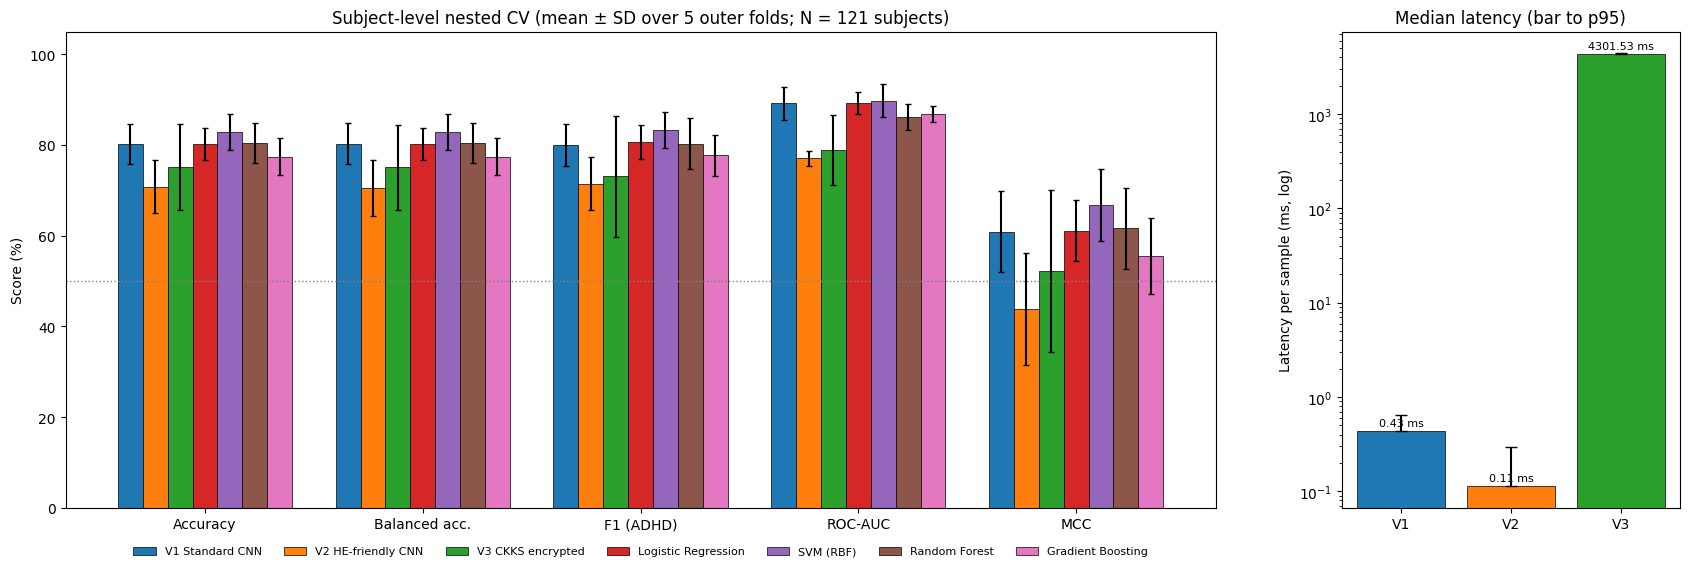

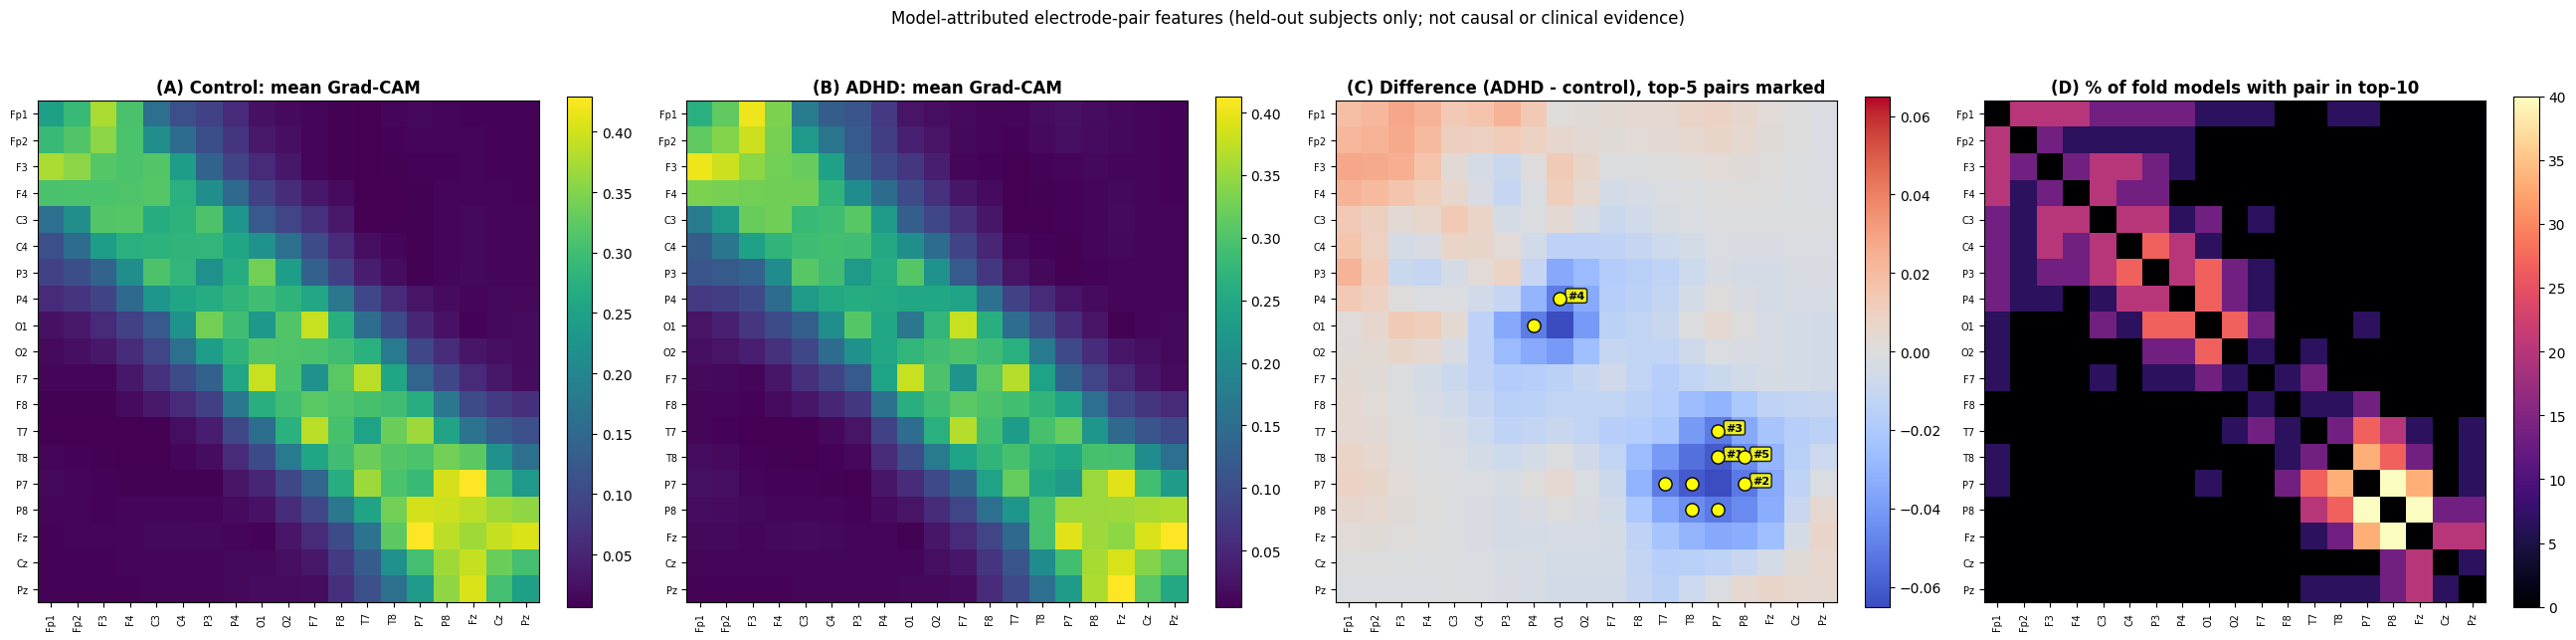

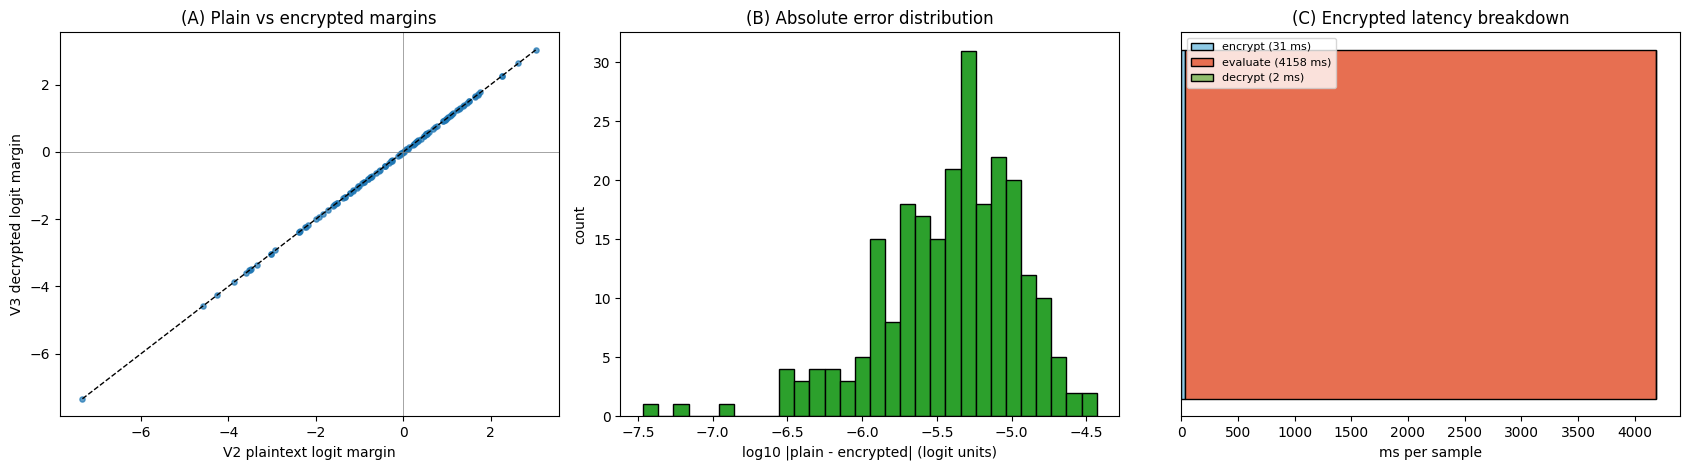

[Figures] Saved fig1_performance_latency.png, fig2_gradcam_heldout.png, fig3_he_fidelity.png in results/


In [9]:
# ==============================================================================
# SECTION 10: Publication figures
# ==============================================================================
# --- Figure 1: performance of all models (mean ± SD over folds) and inference latency (log scale) ---
plot_metrics = ["accuracy", "balanced_accuracy", "f1", "roc_auc", "mcc"]
plot_names = ["Accuracy", "Balanced acc.", "F1 (ADHD)", "ROC-AUC", "MCC"]
cmap = plt.get_cmap("tab10")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5.8), gridspec_kw={"width_ratios": [3.4, 1]})
w = 0.8 / len(MODELS); xs = np.arange(len(plot_metrics))
for i, m in enumerate(MODELS):
    fm = df_fold[df_fold.model == m].groupby("fold")[plot_metrics].mean()
    ax1.bar(xs + (i - (len(MODELS) - 1) / 2) * w, fm.mean() * 100, w, yerr=fm.std(ddof=1) * 100, capsize=2, label=m,
            color=cmap(i), edgecolor="black", linewidth=0.5)
ax1.axhline(50, color="gray", ls=":", lw=1)
ax1.set_xticks(xs); ax1.set_xticklabels(plot_names); ax1.set_ylabel("Score (%)"); ax1.set_ylim(0, 105)
ax1.set_title(f"Subject-level nested CV (mean ± SD over {CFG['n_outer_folds']} outer folds; N = {len(y)} subjects)")
ax1.legend(ncol=len(MODELS), fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.06), frameon=False)
lat = [("V1", df_pred.V1_lat_ms), ("V2", df_pred.V2_lat_ms)] + ([("V3", df_pred.V3_t_total_ms)] if "V3_t_total_ms" in df_pred else [])
med = [np.nanmedian(v) for _, v in lat]; p95 = [np.nanpercentile(v, 95) for _, v in lat]
ax2.bar([n for n, _ in lat], med, color=[cmap(0), cmap(1), cmap(2)][:len(lat)], edgecolor="black", linewidth=0.5)
ax2.errorbar(range(len(lat)), med, yerr=[np.zeros(len(lat)), np.array(p95) - np.array(med)], fmt="none", ecolor="black", capsize=4)
for i, v in enumerate(med):
    ax2.annotate(f"{v:.2f} ms", (i, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8)
ax2.set_yscale("log"); ax2.set_ylabel("Latency per sample (ms, log)"); ax2.set_title("Median latency (bar to p95)")
plt.tight_layout(); plt.savefig(RESULTS / "fig1_performance_latency.png", dpi=300, bbox_inches="tight"); plt.show()

# --- Figure 2: held-out Grad-CAM maps aggregated across fold models ---
def _style(ax):
    ax.set_xticks(range(N_ELEC)); ax.set_yticks(range(N_ELEC))
    ax.set_xticklabels(ELECTRODE_LABELS, rotation=90, fontsize=7); ax.set_yticklabels(ELECTRODE_LABELS, fontsize=7)
freq_map = np.zeros((N_ELEC, N_ELEC)); freq_map[IU] = top_freq; freq_map = freq_map + freq_map.T
fig, axes = plt.subplots(1, 4, figsize=(26, 6.3))
for ax, data, ttl, cm in [(axes[0], mean_control_cam, "(A) Control: mean Grad-CAM", "viridis"), (axes[1], mean_adhd_cam, "(B) ADHD: mean Grad-CAM", "viridis")]:
    im = ax.imshow(data, cmap=cm); ax.set_title(ttl, fontweight="bold"); _style(ax); plt.colorbar(im, ax=ax, fraction=0.046)
vb = max(np.abs(diff_cam).max(), 1e-9)
im = axes[2].imshow(diff_cam, cmap="coolwarm", vmin=-vb, vmax=vb); _style(axes[2]); plt.colorbar(im, ax=axes[2], fraction=0.046)
axes[2].set_title("(C) Difference (ADHD - control), top-5 pairs marked", fontweight="bold")
for rank, p in enumerate(top_5_pairs, 1):
    r, c = p["idx_1"], p["idx_2"]
    axes[2].scatter([c, r], [r, c], s=90, edgecolors="black", facecolors="yellow", zorder=5)
    axes[2].text(c + 0.3, r, f"#{rank}", fontsize=8, fontweight="bold", bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.85))
im = axes[3].imshow(freq_map * 100, cmap="magma", vmin=0); _style(axes[3]); plt.colorbar(im, ax=axes[3], fraction=0.046)
axes[3].set_title(f"(D) % of fold models with pair in top-{TOPK}", fontweight="bold")
plt.suptitle("Model-attributed electrode-pair features (held-out subjects only; not causal or clinical evidence)", y=1.02)
plt.tight_layout(); plt.savefig(RESULTS / "fig2_gradcam_heldout.png", dpi=300, bbox_inches="tight"); plt.show()

# --- Figure 3: V2 vs V3 fidelity and HE latency breakdown ---
if len(d3):
    mp2, mh3 = P2[:, 1] - P2[:, 0], H3[:, 1] - H3[:, 0]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    axes[0].scatter(mp2, mh3, s=14, alpha=0.7); lim = [min(mp2.min(), mh3.min()), max(mp2.max(), mh3.max())]
    axes[0].plot(lim, lim, "k--", lw=1); axes[0].axhline(0, color="gray", lw=0.5); axes[0].axvline(0, color="gray", lw=0.5)
    axes[0].set_xlabel("V2 plaintext logit margin"); axes[0].set_ylabel("V3 decrypted logit margin"); axes[0].set_title("(A) Plain vs encrypted margins")
    e = np.abs(P2 - H3).ravel(); axes[1].hist(np.log10(e + 1e-15), bins=30, color=cmap(2), edgecolor="black")
    axes[1].set_xlabel("log10 |plain - encrypted| (logit units)"); axes[1].set_ylabel("count"); axes[1].set_title("(B) Absolute error distribution")
    parts = [d3.V3_t_enc_ms.mean(), d3.V3_t_eval_ms.mean(), d3.V3_t_dec_ms.mean()]; left = 0
    for lab, v, c in zip(["encrypt", "evaluate", "decrypt"], parts, ["#8ecae6", "#e76f51", "#90be6d"]):
        axes[2].barh([0], [v], left=left, label=f"{lab} ({v:.0f} ms)", color=c, edgecolor="black"); left += v
    axes[2].set_yticks([]); axes[2].set_xlabel("ms per sample"); axes[2].legend(fontsize=8); axes[2].set_title("(C) Encrypted latency breakdown")
    plt.tight_layout(); plt.savefig(RESULTS / "fig3_he_fidelity.png", dpi=300, bbox_inches="tight"); plt.show()
print("[Figures] Saved fig1_performance_latency.png, fig2_gradcam_heldout.png, fig3_he_fidelity.png in results/")


In [10]:
# ==============================================================================
# SECTION 11: Ablations (activation, input representation, architecture) - same subject-level splits
# ==============================================================================
ABLATIONS = {
    "V2 square | full matrix (main)": None,                                            # taken from the main experiment
    "V2 ReLU (plaintext only) | full": dict(kind="v2", activation="relu", rep="full"),
    "V2 square | upper triangle": dict(kind="v2", activation="square", rep="upper"),
    "V1 standard | full matrix (main)": None,
    "V1 standard | upper triangle": dict(kind="v1", activation="square", rep="upper"),
}
import gc
abl_rows = []
for r in range(CFG["n_repeats"]):
    seed_r = CFG["seed"] + 1000 * r
    for k, tr, va, te in make_splits(y, groups, seed_r):          # identical splits to Section 6 (same seeds)
        for name, spec in ABLATIONS.items():
            if spec is None: continue
            Xr = apply_representation(X, spec["rep"])
            mdl, _ = fit_cnn(spec["kind"], Xr[tr], y[tr], Xr[va], y[va], seed_r + k, spec["activation"])
            l = predict_logits(mdl, Xr[te]); s = l[:, 1] - l[:, 0]
            abl_rows.append(dict(model=name, repeat=r, fold=k + 1, n_test=len(te), **compute_metrics(y[te], (s > 0).astype(int), s)))
df_abl = pd.concat([df_fold[df_fold.model.isin(["V2 HE-friendly CNN", "V1 Standard CNN"])].replace(
    {"V2 HE-friendly CNN": "V2 square | full matrix (main)", "V1 Standard CNN": "V1 standard | full matrix (main)"}),
    pd.DataFrame(abl_rows)], ignore_index=True)
df_abl.to_csv(RESULTS / "ablation_fold_level.csv", index=False)
show(summarize(df_abl, list(ABLATIONS), ["accuracy", "balanced_accuracy", "roc_auc", "mcc"]),
     "ABLATIONS: mean ± SD [95% CI] over outer folds, in %")
print("Not run (optional in the checklist): CNN depth / channel-count / pooling ablations. A depth ablation of the HE network is not "
      "possible without changing the architecture, because the depth is fixed by (linear, square, linear).")

# ------------------- CKKS parameter ablation on a fixed subset (uses the repeat-0, fold-1 V2 model) -------------------
CKKS_ABL = {
    "baseline  N=16384 [60,40,40,40,60] scale 2^40": dict(poly_modulus_degree=16384, coeff_mod_bit_sizes=[60, 40, 40, 40, 60], scale_bits=40),
    "smaller   N=8192  [40,30,30,30,40] scale 2^30": dict(poly_modulus_degree=8192, coeff_mod_bit_sizes=[40, 30, 30, 30, 40], scale_bits=30),
    "higher-precision N=16384 [60,50,50,50,60] scale 2^50": dict(poly_modulus_degree=16384, coeff_mod_bit_sizes=[60, 50, 50, 50, 60], scale_bits=50),
}
N_ABL = 10
rec0 = fold_records[0]; m_abl = rec0["model_v2"]; Xs = X[rec0["test_idx"][:N_ABL]]
W1a, Wfa = unroll_he_matrices(m_abl); plain_abl = predict_logits(m_abl, Xs)
ckks_abl = []
for name, cfg_ in CKKS_ABL.items():
    d_ = describe_ckks(cfg_); ctx = None
    try:
        ctx = HE if cfg_ == CKKS_CFG else CKKSInference(**cfg_)          # reuse the main context for the baseline configuration
        ctx.set_model(W1a, Wfa)
        outs = [ctx.infer(x[0].ravel()) for x in Xs]; H = np.stack([o["logits"] for o in outs])
        ckks_abl.append({"config": name, "128-bit secure": d_["meets_128bit_security"], "total coeff bits": d_["total_coeff_modulus_bits"],
                         "max abs err": np.abs(H - plain_abl).max(), "prediction agreement %": ((H.argmax(1) == plain_abl.argmax(1)).mean()) * 100,
                         "mean latency ms": np.mean([o["t_total_ms"] for o in outs]), "ct in MB": outs[0]["ct_in_bytes"] / 1e6,
                         "public ctx MB": ctx.public_context_mb, "keygen s": ctx.keygen_s})
    except Exception as ex:
        ckks_abl.append({"config": name, "128-bit secure": d_["meets_128bit_security"], "error": f"{type(ex).__name__}: {str(ex)[:80]}"})
    if ctx is not None and ctx is not HE:
        del ctx; gc.collect()                                            # each context with Galois keys needs several hundred MB
df_ckks_abl = pd.DataFrame(ckks_abl); df_ckks_abl.to_csv(RESULTS / "ckks_parameter_ablation.csv", index=False)
show(df_ckks_abl, f"CKKS PARAMETER ABLATION ({N_ABL} held-out samples, same trained V2 model)")



ABLATIONS: mean ± SD [95% CI] over outer folds, in %


,Model,K,accuracy,balanced_accuracy,roc_auc,mcc
0,V2 square | full matrix (main),5,"70.8 ± 5.9 [63.5, 78.1]","70.6 ± 6.2 [62.9, 78.3]","77.1 ± 1.6 [75.0, 79.1]","43.8 ± 12.3 [28.5, 59.1]"
1,V2 ReLU (plaintext only) | full,5,"76.6 ± 5.3 [70.1, 83.2]","76.5 ± 5.2 [70.0, 83.0]","82.5 ± 5.4 [75.8, 89.1]","54.8 ± 11.0 [41.2, 68.5]"
2,V2 square | upper triangle,5,"70.2 ± 7.7 [60.7, 79.8]","70.3 ± 7.7 [60.8, 79.8]","74.2 ± 6.8 [65.8, 82.6]","42.9 ± 14.7 [24.6, 61.2]"
3,V1 standard | full matrix (main),5,"80.2 ± 4.5 [74.6, 85.8]","80.2 ± 4.5 [74.6, 85.8]","89.1 ± 3.6 [84.6, 93.7]","60.9 ± 8.9 [49.8, 72.0]"
4,V1 standard | upper triangle,5,"77.7 ± 3.2 [73.8, 81.7]","77.8 ± 3.2 [73.8, 81.8]","87.0 ± 3.1 [83.1, 90.8]","55.9 ± 6.6 [47.7, 64.2]"


Not run (optional in the checklist): CNN depth / channel-count / pooling ablations. A depth ablation of the HE network is not possible without changing the architecture, because the depth is fixed by (linear, square, linear).

CKKS PARAMETER ABLATION (10 held-out samples, same trained V2 model)


,config,128-bit secure,total coeff bits,max abs err,prediction agreement %,mean latency ms,ct in MB,public ctx MB,keygen s
0,"baseline N=16384 [60,40,40,40,60] scale 2^40",True,240,1.157064e-05,100.0,4347.06245,0.855552,122.295492,1.580974
1,"smaller N=8192 [40,30,30,30,40] scale 2^30",True,170,5.335097e-04,100.0,2023.46107,0.320619,43.039431,0.675445
2,"higher-precision N=16384 [60,50,50,50,60] scal...",True,270,9.340777e-07,100.0,4564.86295,0.969215,134.392149,1.456058


In [11]:
# ==============================================================================
# SECTION 13 (optional): External validation on an independent dataset - no tuning on dataset B
# ==============================================================================
if CFG["external_root"]:
    Xb_raw, yb, files_b, groups_b, labels_b = load_eeg_dataset(CFG["external_root"])
    if labels_b != ELECTRODE_LABELS:                                      # harmonise channel order/naming by label
        missing = [e for e in ELECTRODE_LABELS if e not in labels_b]
        if missing:
            raise ValueError(f"External dataset lacks channels {missing}; map old/new names (T3=T7, T4=T8, T5=P7, T6=P8) first.")
        order = [labels_b.index(e) for e in ELECTRODE_LABELS]
        Xb_raw = Xb_raw[:, order][:, :, order]
    Xb = np.stack([zscore_per_sample(m) for m in Xb_raw])[:, None].astype(np.float32)
    # Train ONCE on all of dataset A (subject-level inner validation for early stopping), test ONCE on dataset B
    tr_in, va = next(StratifiedGroupKFold(5, shuffle=True, random_state=CFG["seed"]).split(np.zeros(len(y)), y, groups))
    ext = []
    for name, kind in (("V1 Standard CNN", "v1"), ("V2 HE-friendly CNN", "v2")):
        mdl, _ = fit_cnn(kind, X[tr_in], y[tr_in], X[va], y[va], CFG["seed"]); l = predict_logits(mdl, Xb)
        ext.append(dict(model=name, n=len(yb), **compute_metrics(yb, l.argmax(1), l[:, 1] - l[:, 0])))
    show(pd.DataFrame(ext)[["model", "n", "accuracy", "balanced_accuracy", "sensitivity", "specificity", "roc_auc", "mcc"]].round(3),
         "EXTERNAL VALIDATION (train: dataset A, test: dataset B)")
else:
    print("[External validation] CFG['external_root'] is None -> not run. State this explicitly as a limitation in the paper.")


[External validation] CFG['external_root'] is None -> not run. State this explicitly as a limitation in the paper.


## Threat model and encrypted-inference workflow

    CLIENT (data owner)                                  SERVER (untrusted model host)
    ------------------------------                       --------------------------------------------
    holds: raw EEG, SECRET key                           holds: model weights (plaintext), public
    1. connectivity matrix -> per-sample                        context + Galois/relin keys (NO secret key)
       z-score (needs no training statistics)
    2. CKKS-encrypt the flattened matrix  ------ ct_in ------>  3. ct x W_conv1 -> square -> x W_final
                                                                    (3 levels, all on ciphertexts)
    5. decrypt logits, take argmax        <----- ct_out ------  4. return encrypted logits

- **Encrypted:** the input matrix and the output logits. **Plaintext:** model weights, architecture, CKKS parameters, ciphertext sizes and timing.
- **Server observes:** ciphertext sizes and timing, which are constant for every input, and the public keys. It never sees raw EEG or the secret key.
- **Not protected:** the model itself (weights are known to the server), and the predicted label once the client shares it.
- The code enforces the split: the server context is deserialised from a context serialised *without* the secret key.

## Dataset documentation (fill in from your source; do not leave placeholders in the paper)
- Source / DOI: <fill>. Subjects: N = <fill> (ADHD <fill> / control <fill>); one CSV = <one participant / one epoch>.
- Age, sex, diagnostic criteria, medication status, inclusion/exclusion, ethics/consent: <fill>.
- Acquisition: sampling rate, electrode montage and reference, task vs resting state, recording duration: <fill>.
- Preprocessing: filtering, epoching, artefact removal, **connectivity measure and frequency band(s)**, matrix construction: <fill>.
- Normalisation: per-sample z-score of the whole matrix (independent per sample; no training statistics; runs on the client before encryption).
- If your data derive from the public IEEE DataPort "EEG data for ADHD/Control children" set: its ADHD group had taken methylphenidate for up to 6 months and EEG was recorded during a visual-attention task. Both are confounds to discuss.

## Limitations
Single dataset, 121 subjects, no external validation (unless Section 13 was run); wide confidence intervals; hyperparameters inherited from earlier exploration; possible medication/task confounds; Grad-CAM shows model attribution only and is not evidence of causal or clinical connectivity differences; latency was measured single-threaded on the hardware recorded in `results/environment.json`; not clinically validated and not a diagnostic system.


## Reviewer Q&A (defensible answers)

**Why CKKS?** CKKS supports approximate arithmetic on real vectors, which suits continuous connectivity values without integer quantisation. The cost is small, quantifiable numerical error, which is reported per sample (Section 8).

**Does encryption change predictions?** V3 evaluates exactly the V2 network. We report prediction agreement, disagreement rate and the MAE / median / p95 / max absolute logit error over all encrypted test samples. We make no statistical-equivalence claim from p > 0.05. The optional TOST uses a margin declared in advance.

**Why square activation?** ReLU needs high-degree polynomial approximation and more levels. Square costs one ciphertext multiplication, and the whole network needs 3 rescale levels at N = 16384 (240 modulus bits, within the 128-bit security bound). The price is an accuracy trade-off, measured by V1 vs V2 and the ReLU ablation.

**What do the Grad-CAM maps show?** Electrode-pair features that receive high attribution from the trained V2 models on held-out subjects, with their stability across fold models. They are not causal and not evidence of clinical connectivity differences. Any comparison with the ADHD literature requires a separate literature review.

**Is this clinically usable?** No. It is a research prototype on one small dataset without external validation.
